In [1]:
# Imports and Configuration

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Define paths

data_raw = Path('../data/raw')
set_a = data_raw / 'training_setA'
set_b = data_raw / 'training_setB'

print(f"Set A path exists: {set_a.exists()}")
print(f"Set B path exists: {set_b.exists()}")
print(f"Set A files: {len(list(set_a.glob('*.psv')))}")
print(f"Set B files: {len(list(set_b.glob('*.psv')))}")

Set A path exists: True
Set B path exists: True
Set A files: 20336
Set B files: 20000


In [3]:
# Load all Patient files into one DataFrame

def load_dataset(folder_path, dataset_name):
    """
    Load all .psv files from a folder into single data frame.
    Adds a patient_id column and a dataset column to track which
    hospital each patient came from.
    """
    all_patients = []
    files = list(folder_path.glob('*.psv'))

    for i, file in enumerate(files):
        # Read pipe-separated file
        df = pd.read_csv(file, sep='|')

        # Add patient ID from filename
        df['patient_id'] = file.stem

        # Track which hospital/dataset this came from
        df['dataset'] = dataset_name

        all_patients.append(df)

        # Print Progess every 5000 files
        if (i + 1) % 5000 == 0:
            print(f" Loaded {i+1}/{len(files)} files.")
    
    combined = pd.concat(all_patients, ignore_index=True)
    return combined

print("Loading Set A (20,336 Patients)")
df_a = load_dataset(set_a, 'A')
print(f"Set A loaded: {df_a.shape[0]:,} rows\n")

print("Loadinf Set B (20,000 patients)")
df_b = load_dataset(set_b, 'B')
print(f"Seet B loaded: {df_b.shape[0]:,} rows\n")

# Combine Both sets
df = pd.concat([df_a, df_b], ignore_index=True)
print(f"Combined Dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")

Loading Set A (20,336 Patients)
 Loaded 5000/20336 files.
 Loaded 10000/20336 files.
 Loaded 15000/20336 files.
 Loaded 20000/20336 files.
Set A loaded: 790,215 rows

Loadinf Set B (20,000 patients)
 Loaded 5000/20000 files.
 Loaded 10000/20000 files.
 Loaded 15000/20000 files.
 Loaded 20000/20000 files.
Seet B loaded: 761,995 rows

Combined Dataset: 1,552,210 rows x 43 columns


In [18]:
# Exploration
print("=" * 50)
print("DATASET SHAPE")
print("=" * 50)
print(f"Rows (patient-hours): {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

print("\n" + "=" * 50)
print("COLUMN NAMES")
print("=" * 50)
print(list(df.columns))

print("\n" + "=" * 50)
print("DATA TYPES")
print("=" * 50)
print(df.dtypes)

print("\n" + "=" * 50)
print("FIRST 3 ROWS")
print("=" * 50)
df.tail(10)

DATASET SHAPE
Rows (patient-hours): 1,552,210
Columns: 43

COLUMN NAMES
['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel', 'patient_id', 'dataset']

DATA TYPES
HR                  float64
O2Sat               float64
Temp                float64
SBP                 float64
MAP                 float64
DBP                 float64
Resp                float64
EtCO2               float64
BaseExcess          float64
HCO3                float64
FiO2                float64
pH                  float64
PaCO2               float64
SaO2                float64
AST                 float64
BUN                 float64
Alkalinephos      

,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,...,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,patient_id,dataset
1552200,72.0,98.0,36.6,116.0,88.0,68.0,16.0,NaN,NaN,NaN,...,NaN,62.0,0,NaN,NaN,0.0,26,0,p120000,B
1552201,74.0,98.0,NaN,118.0,88.0,72.0,18.0,NaN,NaN,NaN,...,NaN,62.0,0,NaN,NaN,0.0,27,0,p120000,B
1552202,82.0,97.0,NaN,120.0,82.0,66.0,16.0,NaN,NaN,NaN,...,NaN,62.0,0,NaN,NaN,0.0,28,0,p120000,B
1552203,86.0,97.0,NaN,123.0,89.0,65.0,16.0,NaN,NaN,NaN,...,NaN,62.0,0,NaN,NaN,0.0,29,0,p120000,B
1552204,76.0,98.0,36.4,118.0,82.0,65.0,15.0,NaN,NaN,NaN,...,NaN,62.0,0,NaN,NaN,0.0,30,0,p120000,B
1552205,80.0,96.0,NaN,115.0,87.0,65.0,15.0,NaN,NaN,NaN,...,NaN,62.0,0,NaN,NaN,0.0,31,0,p120000,B
1552206,74.0,97.0,NaN,114.0,83.0,67.0,15.0,NaN,NaN,NaN,...,NaN,62.0,0,NaN,NaN,0.0,32,0,p120000,B
1552207,78.0,98.0,NaN,110.0,83.0,69.0,15.0,NaN,NaN,NaN,...,NaN,62.0,0,NaN,NaN,0.0,33,0,p120000,B
1552208,82.0,99.0,36.6,124.0,91.0,71.0,16.0,NaN,NaN,NaN,...,NaN,62.0,0,NaN,NaN,0.0,34,0,p120000,B
1552209,80.0,97.0,NaN,121.0,97.0,73.0,15.0,NaN,NaN,NaN,...,NaN,62.0,0,NaN,NaN,0.0,35,0,p120000,B


LABEL DISTRIBUTION
No Sepsis (0):  1,524,294 rows (98.20%)
Sepsis (1):     27,916 rows (1.80%)

Imbalance ratio: 55:1


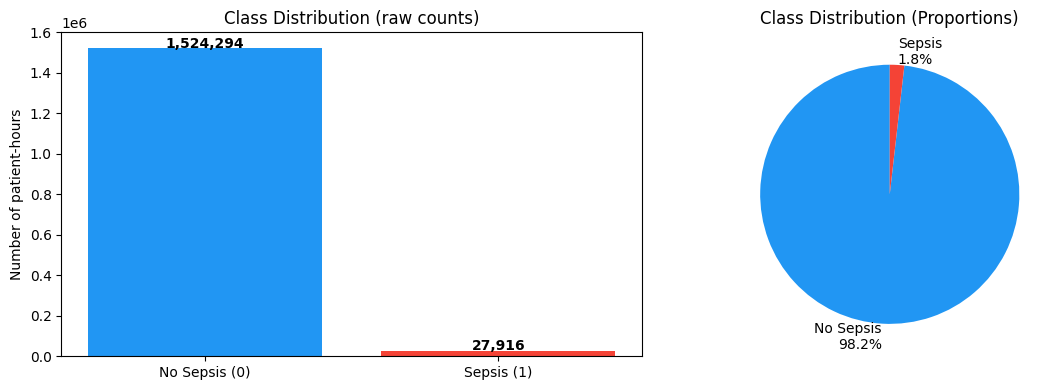


Chart saved to reports/class_distribution.png


In [5]:
# Class distribution (class imbalance)

print("="*50)
print("LABEL DISTRIBUTION")
print("="*50)

sepsis_count = df['SepsisLabel'].value_counts()
sepsis_pct = df['SepsisLabel'].value_counts(normalize=True) * 100

print(f"No Sepsis (0): {sepsis_count[0]:>10,} rows ({sepsis_pct[0]:.2f}%)")
print(f"Sepsis (1): {sepsis_count[1]:>10,} rows ({sepsis_pct[1]:.2f}%)")
print(f"\nImbalance ratio: {sepsis_count[0]/sepsis_count[1]:.0f}:1")

# Visualise it
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar Chart
axes[0].bar(['No Sepsis (0)', 'Sepsis (1)'],
            sepsis_count.values,
            color=['#2196F3', '#F44336'])
axes[0].set_title('Class Distribution (raw counts)')
axes[0].set_ylabel('Number of patient-hours')

for i,v in enumerate(sepsis_count.values):
    axes[0].text(i, v+1000, f'{v:,}', ha='center', fontweight='bold')

# Pie Chart
axes[1].pie(sepsis_count.values,
            labels=[f'No Sepsis\n{sepsis_pct[0]:.1f}%',
                    f'Sepsis\n{sepsis_pct[1]:.1f}%'],
            colors=['#2196F3', '#F44336'],
            startangle = 90)
axes[1].set_title('Class Distribution (Proportions)')

plt.tight_layout()
plt.savefig('../reports/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved to reports/class_distribution.png")

MISSING DATA ANALYSIS
                  Missing Count  Missing %
Bilirubin_direct        1549220  99.807371
Fibrinogen              1541968  99.340167
TroponinI               1537429  99.047745
Bilirubin_total         1529069  98.509158
Alkalinephos            1527269  98.393194
AST                     1527027  98.377604
Lactate                 1510764  97.329872
PTT                     1506511  97.055875
SaO2                    1498649  96.549372
EtCO2                   1494574  96.286843
Phosphate               1489909  95.986303
HCO3                    1487182  95.810618
Chloride                1481744  95.460279
BaseExcess              1468065  94.579020
PaCO2                   1465909  94.440121
Calcium                 1460879  94.116067
Platelets               1460001  94.059502
Creatinine              1457594  93.904433
Magnesium               1454259  93.689578
WBC                     1452763  93.593199
BUN                     1445642  93.134434
pH                      1444637 

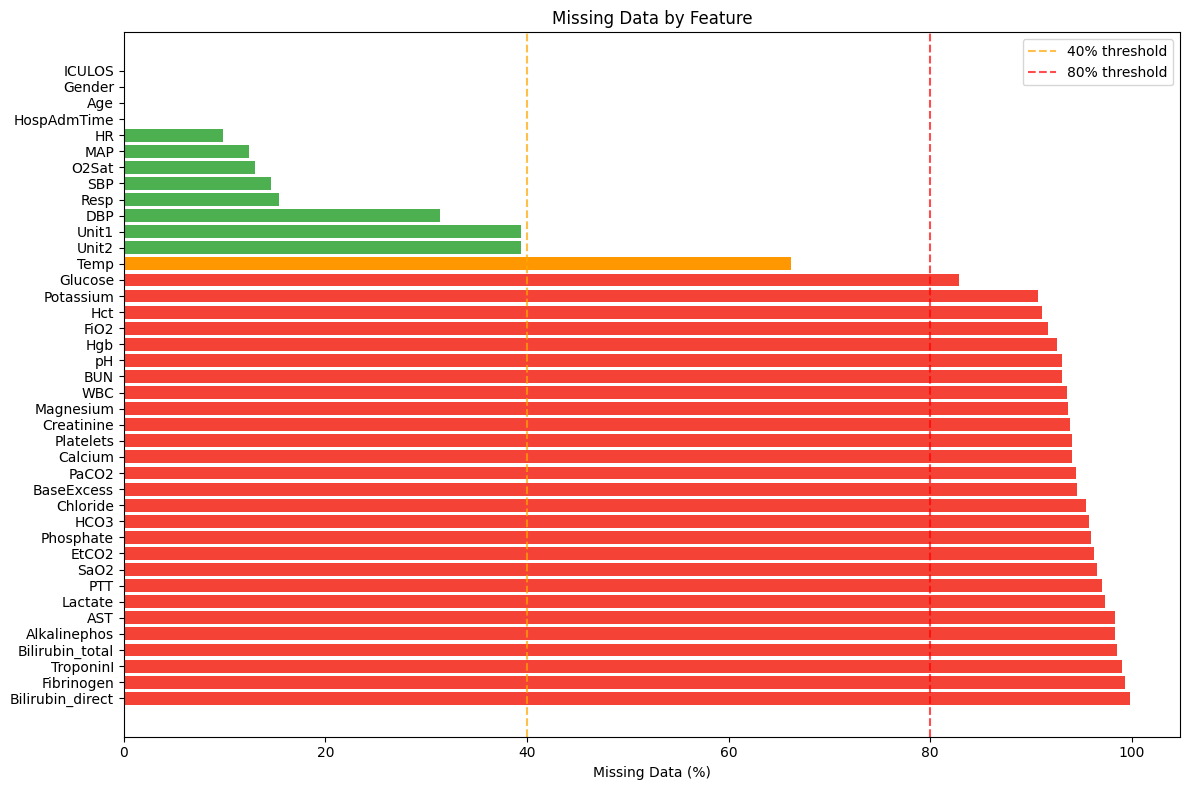


Chart saved to reports/missing_data.png


In [6]:
# Missing data analysis
print("=" * 50)
print("MISSING DATA ANALYSIS")
print("=" * 50)

# Calculate missing percentage for each column
clinical_cols = [c for c in df.columns if c not in ['patient_id', 'dataset', 'SepsisLabel']]
missing = df[clinical_cols].isnull().sum()
missing_pct = (df[clinical_cols].isnull().sum()/len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print(missing_df.to_string())

# Visualise
plt.figure(figsize=(12,8))
colors = ['#F44336' if x > 80 else '#FF9800' if x > 40 else '#4CAF50'
          for x in missing_df['Missing %']]
bars = plt.barh(missing_df.index, missing_df['Missing %'], color=colors)
plt.xlabel('Missing Data (%)')
plt.title('Missing Data by Feature')
plt.axvline(x=40, color='orange', linestyle='--', alpha=0.7, label='40% threshold')
plt.axvline(x=80, color='red', linestyle='--', alpha=0.7, label='80% threshold')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/missing_data.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved to reports/missing_data.png")


VITAL SIGNS STATISTICS

Vital signs in SEPSIS hours:
          HR   O2Sat   Temp     SBP     MAP     DBP   Resp
mean   90.79   96.99  37.25  121.45   80.17   62.02  20.46
std    19.01    3.26   1.05   24.99   16.63   14.10   6.14
min    36.00   39.00  30.50   25.00   22.00   21.00   1.00
max   200.00  100.00  40.90  280.00  280.00  274.00  76.00

Vital signs in NON-SEPSIS hours:
          HR   O2Sat   Temp     SBP     MAP     DBP    Resp
mean   84.47   97.20  36.97  123.79   82.44   63.86   18.69
std    17.27    2.93   0.76   23.20   16.33   13.95    5.07
min    20.00   20.00  20.90   20.00   20.00   20.00    1.00
max   280.00  100.00  50.00  300.00  300.00  300.00  100.00


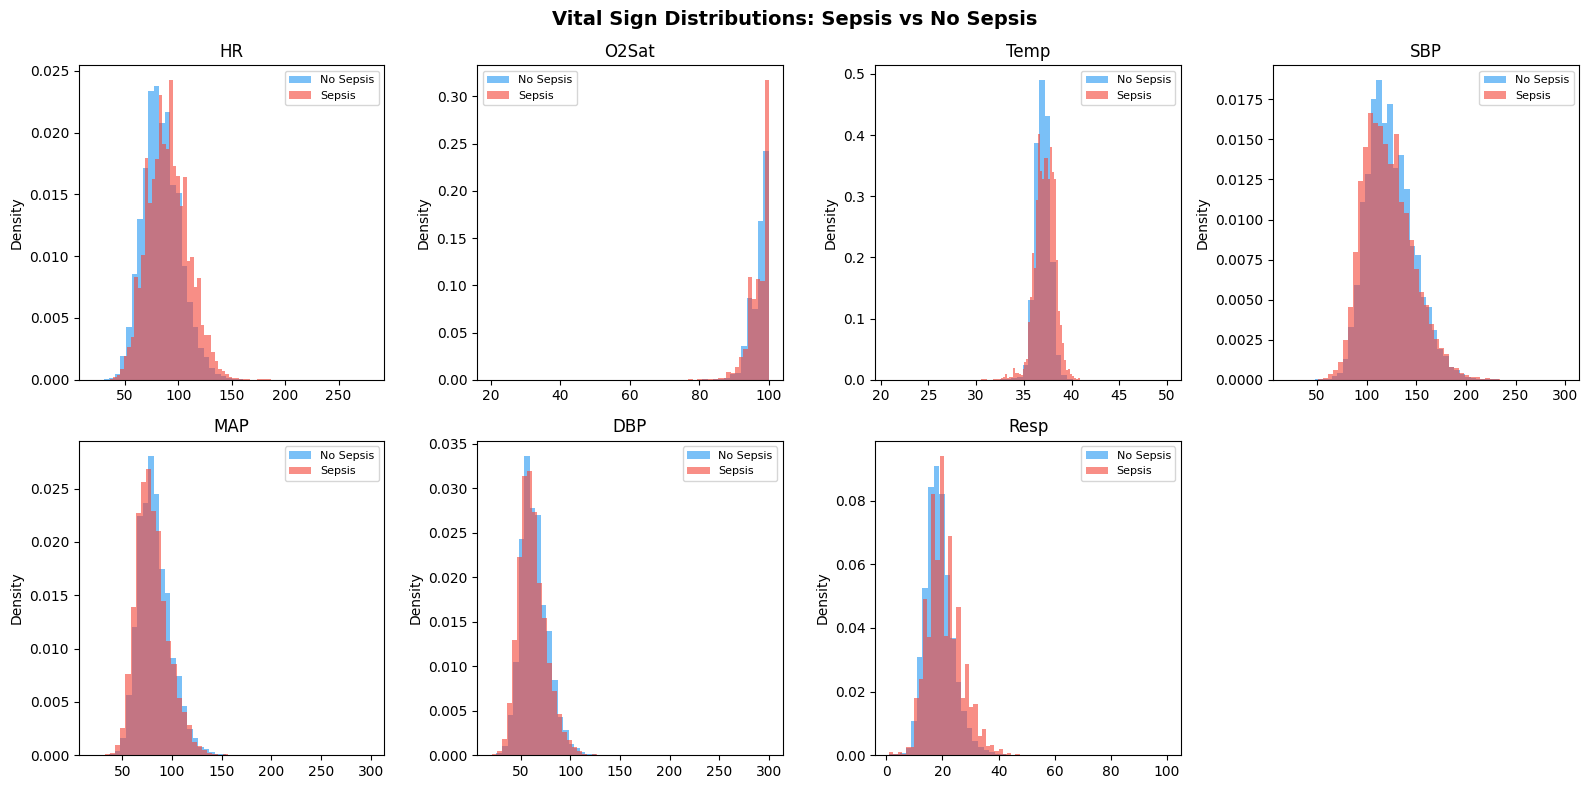


Chart saved to reports/vital_distributions.png


In [7]:
# Vital signs exploration (our most reliable features)
print("=" * 50)
print("VITAL SIGNS STATISTICS")
print("=" * 50)

vital_cols = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp']

# Compare vitals between sepsis and non-sepsis patients
sepsis_vitals = df[df['SepsisLabel'] == 1][vital_cols].describe().round(2)
normal_vitals = df[df['SepsisLabel'] == 0][vital_cols].describe().round(2)

print("\nVital signs in SEPSIS hours:")
print(sepsis_vitals.loc[['mean', 'std', 'min', 'max']])

print("\nVital signs in NON-SEPSIS hours:")
print(normal_vitals.loc[['mean', 'std', 'min', 'max']])

# Visualise distributions
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(vital_cols):
    sepsis_data = df[df['SepsisLabel'] == 1][col].dropna()
    normal_data = df[df['SepsisLabel'] == 0][col].dropna()
    
    axes[i].hist(normal_data, bins=50, alpha=0.6, 
                 color='#2196F3', label='No Sepsis', density=True)
    axes[i].hist(sepsis_data, bins=50, alpha=0.6, 
                 color='#F44336', label='Sepsis', density=True)
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel('Density')

# Hide the empty 8th subplot
axes[7].set_visible(False)

plt.suptitle('Vital Sign Distributions: Sepsis vs No Sepsis', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/vital_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved to reports/vital_distributions.png")

ICU STAY LENGTH ANALYSIS
Average ICU stay: 39.0 hours
Median ICU stay:  39.0 hours
Shortest stay:    8 hours
Longest stay:     336 hours

SEPSIS PATIENT ANALYSIS
Total patients:            40,336
Patients who got sepsis:   2,932
Sepsis rate (patient level): 7.3%

Sepsis onset timing:
  Average hour of onset: 50.9h into ICU stay
  Median hour of onset:  29.0h into ICU stay
  Earliest onset:        hour 1
  Latest onset:          hour 331


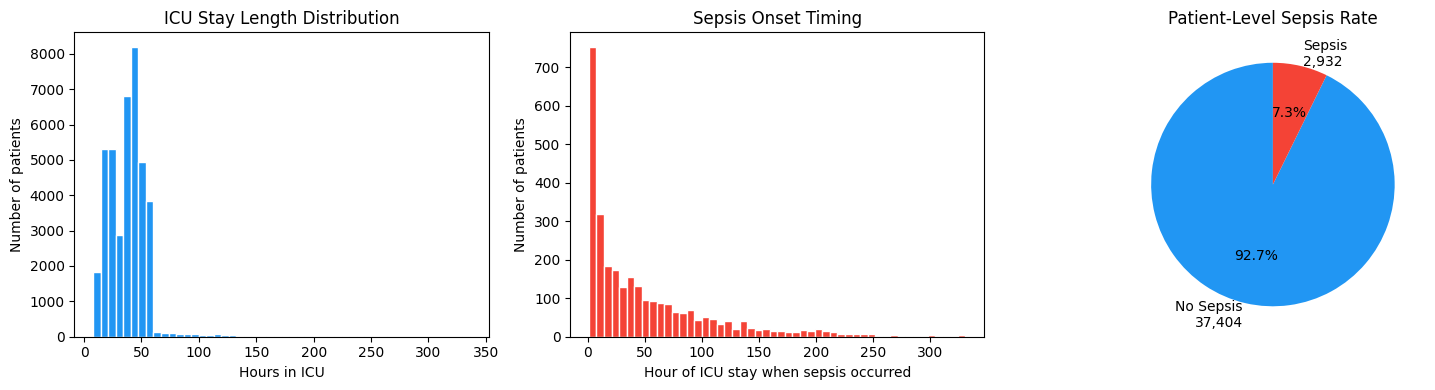


Chart saved to reports/sepsis_timing.png


In [8]:
# Cell 7 - ICU stay length and sepsis timing analysis
print("=" * 50)
print("ICU STAY LENGTH ANALYSIS")
print("=" * 50)

# Get stay length per patient
stay_lengths = df.groupby('patient_id')['ICULOS'].max()
print(f"Average ICU stay: {stay_lengths.mean():.1f} hours")
print(f"Median ICU stay:  {stay_lengths.median():.1f} hours")
print(f"Shortest stay:    {stay_lengths.min()} hours")
print(f"Longest stay:     {stay_lengths.max()} hours")

print("\n" + "=" * 50)
print("SEPSIS PATIENT ANALYSIS")
print("=" * 50)

# Find patients who developed sepsis
sepsis_patients = df[df['SepsisLabel'] == 1]['patient_id'].unique()
total_patients = df['patient_id'].nunique()
print(f"Total patients:            {total_patients:,}")
print(f"Patients who got sepsis:   {len(sepsis_patients):,}")
print(f"Sepsis rate (patient level): {len(sepsis_patients)/total_patients*100:.1f}%")

# When in their stay did sepsis occur?
sepsis_timing = df[df['SepsisLabel'] == 1].groupby('patient_id')['ICULOS'].min()
print(f"\nSepsis onset timing:")
print(f"  Average hour of onset: {sepsis_timing.mean():.1f}h into ICU stay")
print(f"  Median hour of onset:  {sepsis_timing.median():.1f}h into ICU stay")
print(f"  Earliest onset:        hour {sepsis_timing.min()}")
print(f"  Latest onset:          hour {sepsis_timing.max()}")

# Visualise
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Stay length distribution
axes[0].hist(stay_lengths, bins=50, color='#2196F3', edgecolor='white')
axes[0].set_title('ICU Stay Length Distribution')
axes[0].set_xlabel('Hours in ICU')
axes[0].set_ylabel('Number of patients')

# Sepsis onset timing
axes[1].hist(sepsis_timing, bins=50, color='#F44336', edgecolor='white')
axes[1].set_title('Sepsis Onset Timing')
axes[1].set_xlabel('Hour of ICU stay when sepsis occurred')
axes[1].set_ylabel('Number of patients')

# Sepsis vs non-sepsis patients (pie)
axes[2].pie(
    [total_patients - len(sepsis_patients), len(sepsis_patients)],
    labels=[f'No Sepsis\n{total_patients - len(sepsis_patients):,}', 
            f'Sepsis\n{len(sepsis_patients):,}'],
    colors=['#2196F3', '#F44336'],
    autopct='%1.1f%%',
    startangle=90
)
axes[2].set_title('Patient-Level Sepsis Rate')

plt.tight_layout()
plt.savefig('../reports/sepsis_timing.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved to reports/sepsis_timing.png")

LAB VALUE AVAILABILITY NEAR SEPSIS ONSET

% of sepsis patients with lab value available, by hours to onset:
                Lactate   WBC  Creatinine  Glucose  Platelets  HCO3    pH   Hgb
hours_to_onset                                                                 
-24                 5.0   8.1         7.5     18.3        7.2   5.4   9.5   8.7
-23                 3.7   6.8         7.1     18.1        5.9   4.8   9.1   7.5
-22                 4.4   6.5         6.1     16.7        5.5   4.8   9.3   7.4
-21                 5.0   5.5         5.0     15.5        4.9   4.1   9.3   6.4
-20                 4.1   6.5         6.8     18.2        5.8   5.4   9.7   7.2
-19                 4.2   6.8         6.3     17.7        5.7   5.7   9.0   7.3
-18                 4.7   8.1         6.2     16.8        6.7   5.9  10.0   8.9
-17                 5.5   7.6         7.5     18.7        6.9   6.3  10.8   8.3
-16                 4.4   8.3         7.6     18.4        7.0   7.7   9.9   8.8
-15         

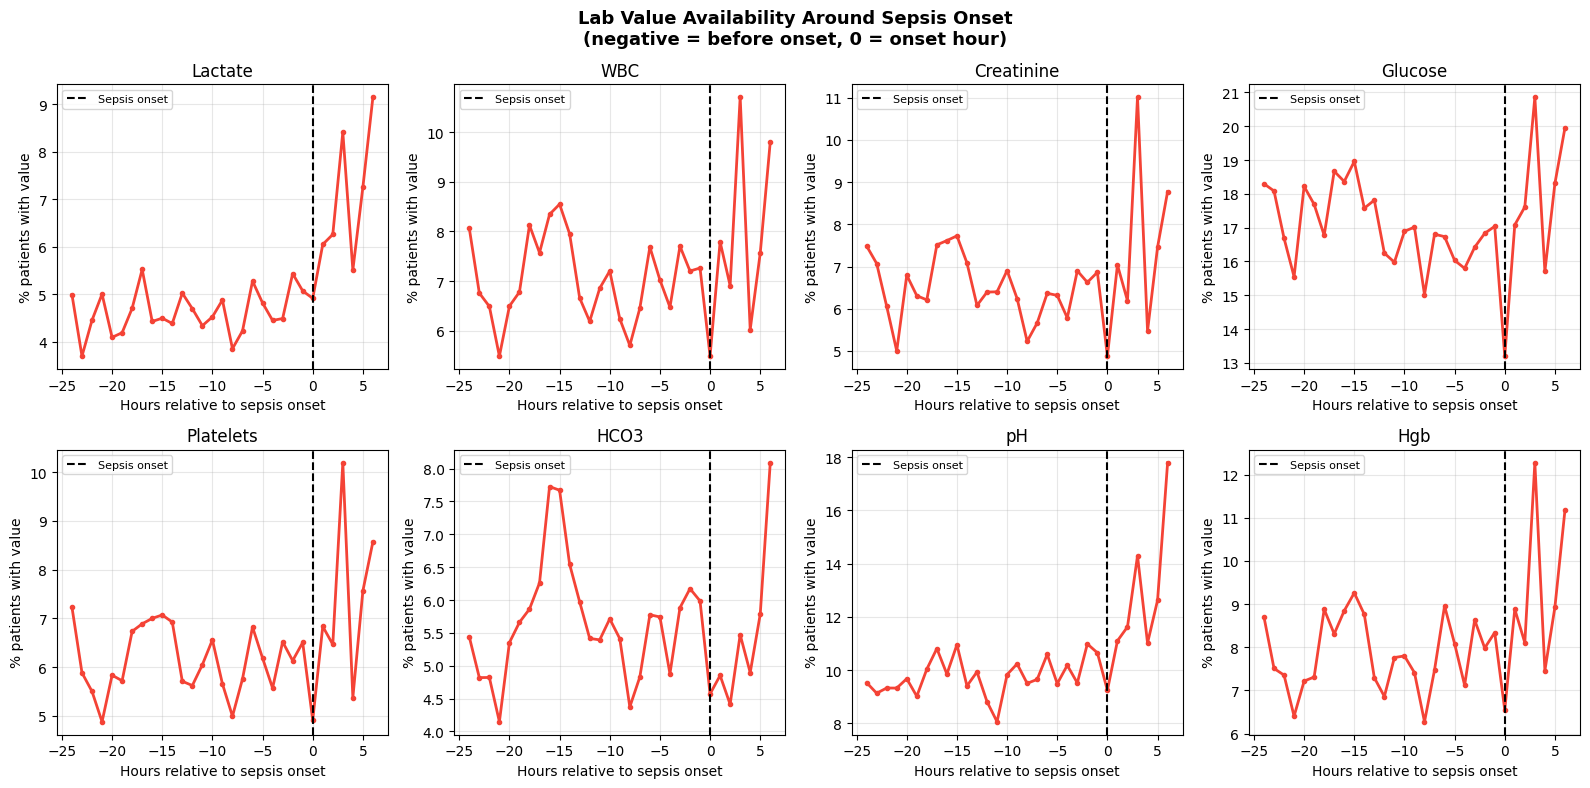

In [9]:
# Informative missingness analysis
# Do lab values start appearing more frequently as sepsis approaches?

print("=" * 50)
print("LAB VALUE AVAILABILITY NEAR SEPSIS ONSET")
print("=" * 50)

# Focus on patients who developed sepsis
sepsis_patient_ids = df[df['SepsisLabel'] == 1]['patient_id'].unique()
df_sepsis_pts = df[df['patient_id'].isin(sepsis_patient_ids)].copy()

# For each patient, find their sepsis onset hour
onset_hours = df[df['SepsisLabel'] == 1].groupby('patient_id')['ICULOS'].min()
df_sepsis_pts['onset_hour'] = df_sepsis_pts['patient_id'].map(onset_hours)

# Create hours_to_onset column (negative = before sepsis, 0 = onset hour)
df_sepsis_pts['hours_to_onset'] = df_sepsis_pts['ICULOS'] - df_sepsis_pts['onset_hour']

# Focus on window: 24 hours before to 6 hours after onset
window = df_sepsis_pts[
    (df_sepsis_pts['hours_to_onset'] >= -24) & 
    (df_sepsis_pts['hours_to_onset'] <= 6)
].copy()

# For each hour relative to onset, what % of patients have each lab value?
lab_cols = ['Lactate', 'WBC', 'Creatinine', 'Glucose', 
            'Platelets', 'HCO3', 'pH', 'Hgb']

availability = {}
for col in lab_cols:
    avail_by_hour = window.groupby('hours_to_onset')[col].apply(
        lambda x: x.notna().sum() / len(x) * 100
    )
    availability[col] = avail_by_hour

avail_df = pd.DataFrame(availability)

print("\n% of sepsis patients with lab value available, by hours to onset:")
print(avail_df.round(1).to_string())

# Visualise
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(lab_cols):
    axes[i].plot(avail_df.index, avail_df[col], 
                 color='#F44336', linewidth=2, marker='o', markersize=3)
    axes[i].axvline(x=0, color='black', linestyle='--', 
                    linewidth=1.5, label='Sepsis onset')
    axes[i].set_title(col)
    axes[i].set_xlabel('Hours relative to sepsis onset')
    axes[i].set_ylabel('% patients with value')
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Lab Value Availability Around Sepsis Onset\n(negative = before onset, 0 = onset hour)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/informative_missingness.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Document our feature engineering decisions
print("=" * 60)
print("FEATURE ENGINEERING DECISIONS")
print("=" * 60)

print("""
FEATURES WE WILL USE:
---------------------
Tier 1 - Core vitals (reliable, <31% missing):
  HR, O2Sat, SBP, MAP, DBP, Resp, Temp

Tier 2 - Key lab values (sparse but clinically vital):
  Lactate, WBC, Creatinine, Glucose, pH, Hgb

Tier 3 - Demographics (always available):
  Age, Gender, HospAdmTime, ICULOS

INFORMATIVE MISSINGNESS:
------------------------
For each Tier 2 lab value, we will add a binary indicator:
  e.g. Lactate_available: 1 if recorded this hour, 0 if not
This captures the clinical signal of "a lab was ordered"
without leaking post-onset information.

FEATURES WE WILL DROP:
-----------------------
- EtCO2: 96% missing, rarely used clinically
- Unit1, Unit2: 39% missing, administrative not clinical  
- Bilirubin_direct/total: 99% missing
- Fibrinogen, TroponinI, Alkalinephos: 99% missing
- PTT, SaO2, PaCO2, BaseExcess: >94% missing
- Phosphate, HCO3, Magnesium: >95% missing
- Calcium, Chloride, BUN: >93% missing
- Potassium: 90% missing
- AST: 98% missing
- FiO2: 91% missing

PREDICTION HORIZON:
-------------------
Target: Will sepsis occur within the NEXT 6 hours?
This gives clinicians time to intervene before onset.

IMPUTATION STRATEGY:
--------------------
1. Forward-fill within each patient (carry last known value)
2. Median imputation for remaining NaN at start of stay
3. Scale all features to [0,1] range for LSTM stability
""")

print("Ready for Phase 3 - Preprocessing!")

FEATURE ENGINEERING DECISIONS

FEATURES WE WILL USE:
---------------------
Tier 1 - Core vitals (reliable, <31% missing):
  HR, O2Sat, SBP, MAP, DBP, Resp, Temp

Tier 2 - Key lab values (sparse but clinically vital):
  Lactate, WBC, Creatinine, Glucose, pH, Hgb

Tier 3 - Demographics (always available):
  Age, Gender, HospAdmTime, ICULOS

INFORMATIVE MISSINGNESS:
------------------------
For each Tier 2 lab value, we will add a binary indicator:
  e.g. Lactate_available: 1 if recorded this hour, 0 if not
This captures the clinical signal of "a lab was ordered"
without leaking post-onset information.

FEATURES WE WILL DROP:
-----------------------
- EtCO2: 96% missing, rarely used clinically
- Unit1, Unit2: 39% missing, administrative not clinical  
- Bilirubin_direct/total: 99% missing
- Fibrinogen, TroponinI, Alkalinephos: 99% missing
- PTT, SaO2, PaCO2, BaseExcess: >94% missing
- Phosphate, HCO3, Magnesium: >95% missing
- Calcium, Chloride, BUN: >93% missing
- Potassium: 90% missing


LAB VALUES COMPARISON: Sepsis vs Non-Sepsis Patients

Pre-onset sepsis hours: 144,494
Non-sepsis hours: 1,379,800

MEAN VALUES WHEN LAB IS ACTUALLY RECORDED

Feature           Sepsis (pre-onset)       No Sepsis   Difference
-----------------------------------------------------------------
Lactate                    2.64 ± 2.29        2.64 ± 2.56  ↓ 0.2%
WBC                       12.31 ± 7.72       11.29 ± 7.66  ↑ 9.1%
Creatinine                 1.59 ± 1.59        1.49 ± 1.83  ↑ 6.8%
Glucose                  137.65 ± 47.11      136.79 ± 51.68  ↑ 0.6%
pH                         7.39 ± 0.08        7.38 ± 0.07  ↑ 0.1%
Hgb                       10.18 ± 1.86       10.47 ± 1.98  ↓ 2.8%


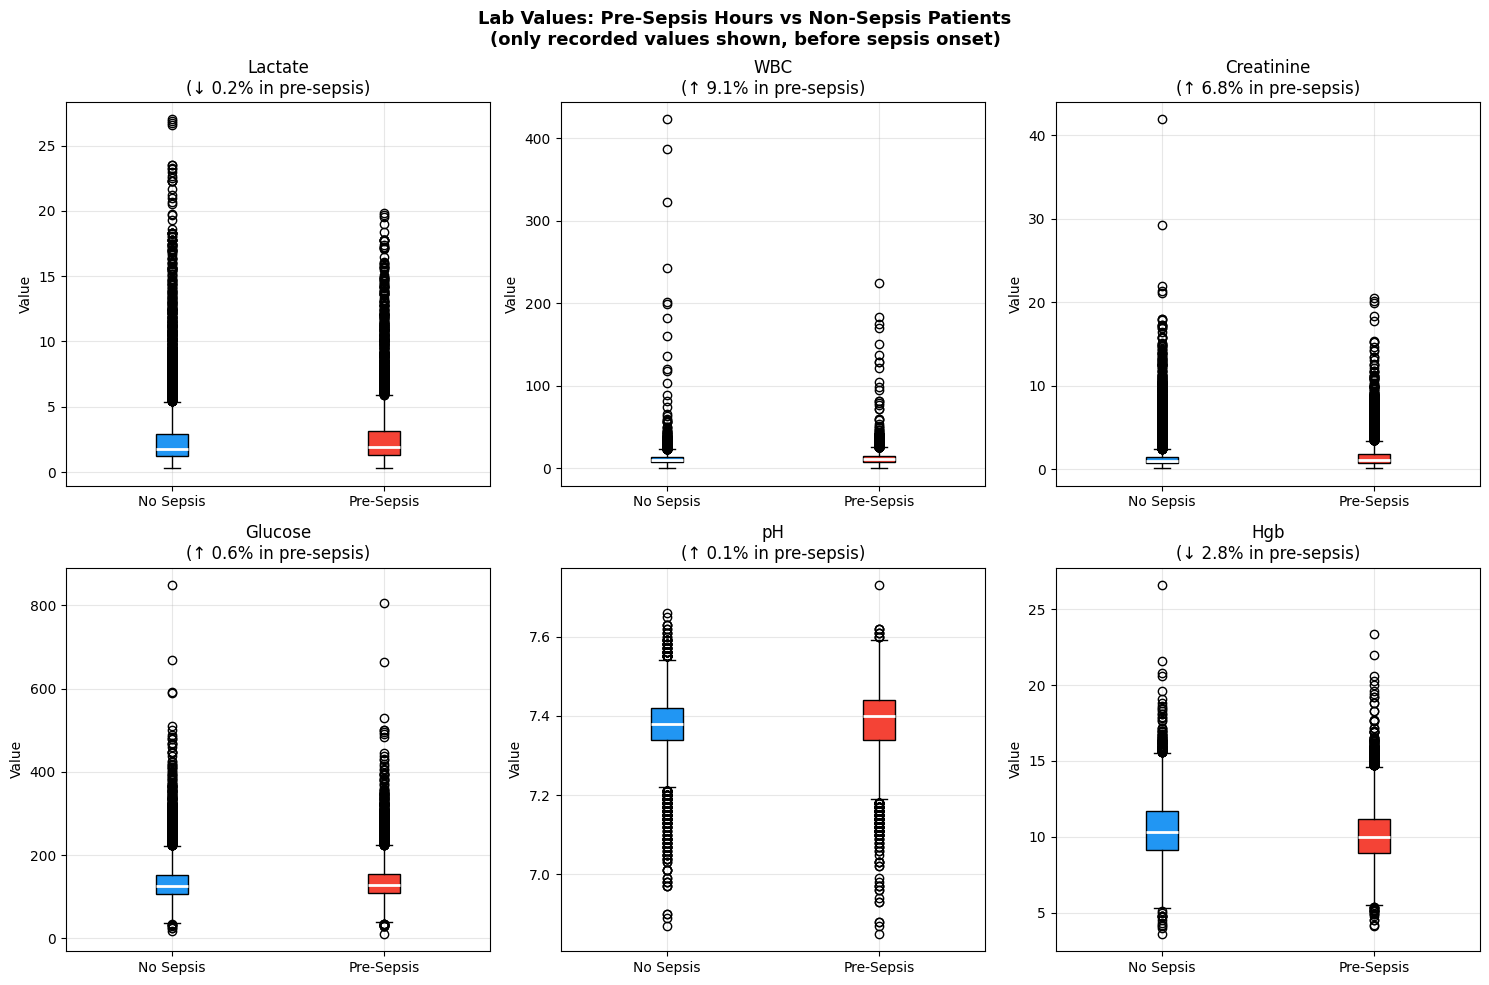

In [11]:
# Actual lab VALUES comparison: sepsis vs non-sepsis patients
# Only looking at hours BEFORE onset (to avoid data leakage)
# For non-sepsis patients, we use their entire stay

print("=" * 60)
print("LAB VALUES COMPARISON: Sepsis vs Non-Sepsis Patients")
print("=" * 60)

lab_cols = ['Lactate', 'WBC', 'Creatinine', 'Glucose', 'pH', 'Hgb']

# Get sepsis patients - only hours BEFORE onset
sepsis_ids = df[df['SepsisLabel'] == 1]['patient_id'].unique()
onset_map = df[df['SepsisLabel'] == 1].groupby('patient_id')['ICULOS'].min()

# Build pre-onset dataframe for sepsis patients
pre_onset_rows = []
for pid in sepsis_ids:
    onset = onset_map[pid]
    patient_data = df[
        (df['patient_id'] == pid) & 
        (df['ICULOS'] < onset)  # strictly BEFORE onset
    ]
    pre_onset_rows.append(patient_data)

df_pre_sepsis = pd.concat(pre_onset_rows, ignore_index=True)

# Non-sepsis patients - entire stay
df_no_sepsis = df[~df['patient_id'].isin(sepsis_ids)]

print(f"\nPre-onset sepsis hours: {len(df_pre_sepsis):,}")
print(f"Non-sepsis hours: {len(df_no_sepsis):,}")

# Compare actual values
print("\n" + "=" * 60)
print("MEAN VALUES WHEN LAB IS ACTUALLY RECORDED")
print("=" * 60)
print(f"\n{'Feature':<15} {'Sepsis (pre-onset)':>20} {'No Sepsis':>15} {'Difference':>12}")
print("-" * 65)

results = {}
for col in lab_cols:
    sepsis_vals = df_pre_sepsis[col].dropna()
    normal_vals = df_no_sepsis[col].dropna()
    
    sep_mean = sepsis_vals.mean()
    nor_mean = normal_vals.mean()
    diff_pct = ((sep_mean - nor_mean) / nor_mean) * 100
    
    results[col] = {
        'sepsis_mean': sep_mean,
        'sepsis_std': sepsis_vals.std(),
        'sepsis_n': len(sepsis_vals),
        'normal_mean': nor_mean,
        'normal_std': normal_vals.std(),
        'normal_n': len(normal_vals),
        'diff_pct': diff_pct
    }
    
    direction = "↑" if diff_pct > 0 else "↓"
    print(f"{col:<15} {sep_mean:>15.2f} ± {results[col]['sepsis_std']:.2f}"
          f"  {nor_mean:>10.2f} ± {results[col]['normal_std']:.2f}"
          f"  {direction} {abs(diff_pct):.1f}%")

# Visualise with box plots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(lab_cols):
    sepsis_vals = df_pre_sepsis[col].dropna()
    normal_vals = df_no_sepsis[col].dropna()
    
    # Use sample for speed if too many points
    if len(normal_vals) > 10000:
        normal_vals = normal_vals.sample(10000, random_state=42)
    if len(sepsis_vals) > 10000:
        sepsis_vals = sepsis_vals.sample(10000, random_state=42)
    
    data_to_plot = [normal_vals.values, sepsis_vals.values]
    bp = axes[i].boxplot(data_to_plot, 
                          labels=['No Sepsis', 'Pre-Sepsis'],
                          patch_artist=True,
                          medianprops=dict(color='white', linewidth=2))
    
    bp['boxes'][0].set_facecolor('#2196F3')
    bp['boxes'][1].set_facecolor('#F44336')
    
    diff = results[col]['diff_pct']
    direction = "↑" if diff > 0 else "↓"
    axes[i].set_title(f'{col}\n({direction} {abs(diff):.1f}% in pre-sepsis)')
    axes[i].set_ylabel('Value')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Lab Values: Pre-Sepsis Hours vs Non-Sepsis Patients\n'
             '(only recorded values shown, before sepsis onset)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/lab_values_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Feature decision based on evidence
print("=" * 60)
print("FINAL FEATURE DECISION - EVIDENCE BASED")
print("=" * 60)

print("""
WHAT THE DATA TOLD US:
----------------------
1. Lab values show only small mean differences before sepsis onset
   (WBC +9.1%, Creatinine +6.8%, others <3%)
   
2. BUT individual snapshots are not the point — our LSTM reads
   TRENDS over time. A rising Lactate matters more than its 
   absolute value.

3. Informative missingness is real but occurs AT/AFTER onset,
   not reliably before. Binary indicators still useful as a
   weak signal.

FINAL FEATURE SET:
------------------
Core vitals (recorded hourly):
  HR, O2Sat, SBP, MAP, DBP, Resp, Temp

Key labs (sparse but trend-informative):
  Lactate, WBC, Creatinine, Glucose, pH, Hgb

Demographics (static):
  Age, Gender, HospAdmTime, ICULOS

Missingness indicators (one per lab):
  Lactate_obs, WBC_obs, Creatinine_obs, 
  Glucose_obs, pH_obs, Hgb_obs

TOTAL FEATURES: 7 vitals + 6 labs + 4 demographics + 6 indicators
             = 23 features per hour

WHAT WE DROPPED AND WHY:
-------------------------
- EtCO2, PTT, SaO2, PaCO2 etc: >94% missing, no trend possible
- Unit1, Unit2: administrative, not clinical signal
- Bilirubin, Fibrinogen, TroponinI: ~99% missing, unusable
""")

print("Exploration complete. Moving to Phase 3 - Preprocessing!")

FINAL FEATURE DECISION - EVIDENCE BASED

WHAT THE DATA TOLD US:
----------------------
1. Lab values show only small mean differences before sepsis onset
   (WBC +9.1%, Creatinine +6.8%, others <3%)

2. BUT individual snapshots are not the point — our LSTM reads
   TRENDS over time. A rising Lactate matters more than its 
   absolute value.

3. Informative missingness is real but occurs AT/AFTER onset,
   not reliably before. Binary indicators still useful as a
   weak signal.

FINAL FEATURE SET:
------------------
Core vitals (recorded hourly):
  HR, O2Sat, SBP, MAP, DBP, Resp, Temp

Key labs (sparse but trend-informative):
  Lactate, WBC, Creatinine, Glucose, pH, Hgb

Demographics (static):
  Age, Gender, HospAdmTime, ICULOS

Missingness indicators (one per lab):
  Lactate_obs, WBC_obs, Creatinine_obs, 
  Glucose_obs, pH_obs, Hgb_obs

TOTAL FEATURES: 7 vitals + 6 labs + 4 demographics + 6 indicators
             = 23 features per hour

WHAT WE DROPPED AND WHY:
-----------------------

In [13]:
# Individual patient journeys: vitals over time until sepsis onset

# Pick 6 interesting sepsis patients - ones with decent data
# Find patients who had sepsis onset after at least 12 hours (enough data to show trends)
onset_hours = df[df['SepsisLabel'] == 1].groupby('patient_id')['ICULOS'].min()
good_patients = onset_hours[onset_hours >= 12].index.tolist()

# Pick 6 patients
import random
random.seed(42)
selected_patients = random.sample(good_patients, 6)

print("Selected patients and their sepsis onset hours:")
for pid in selected_patients:
    onset = onset_hours[pid]
    print(f"  {pid}: sepsis at hour {onset}")

Selected patients and their sepsis onset hours:
  p101601: sepsis at hour 39
  p003639: sepsis at hour 65
  p000765: sepsis at hour 54
  p107525: sepsis at hour 33
  p009313: sepsis at hour 86
  p008490: sepsis at hour 278


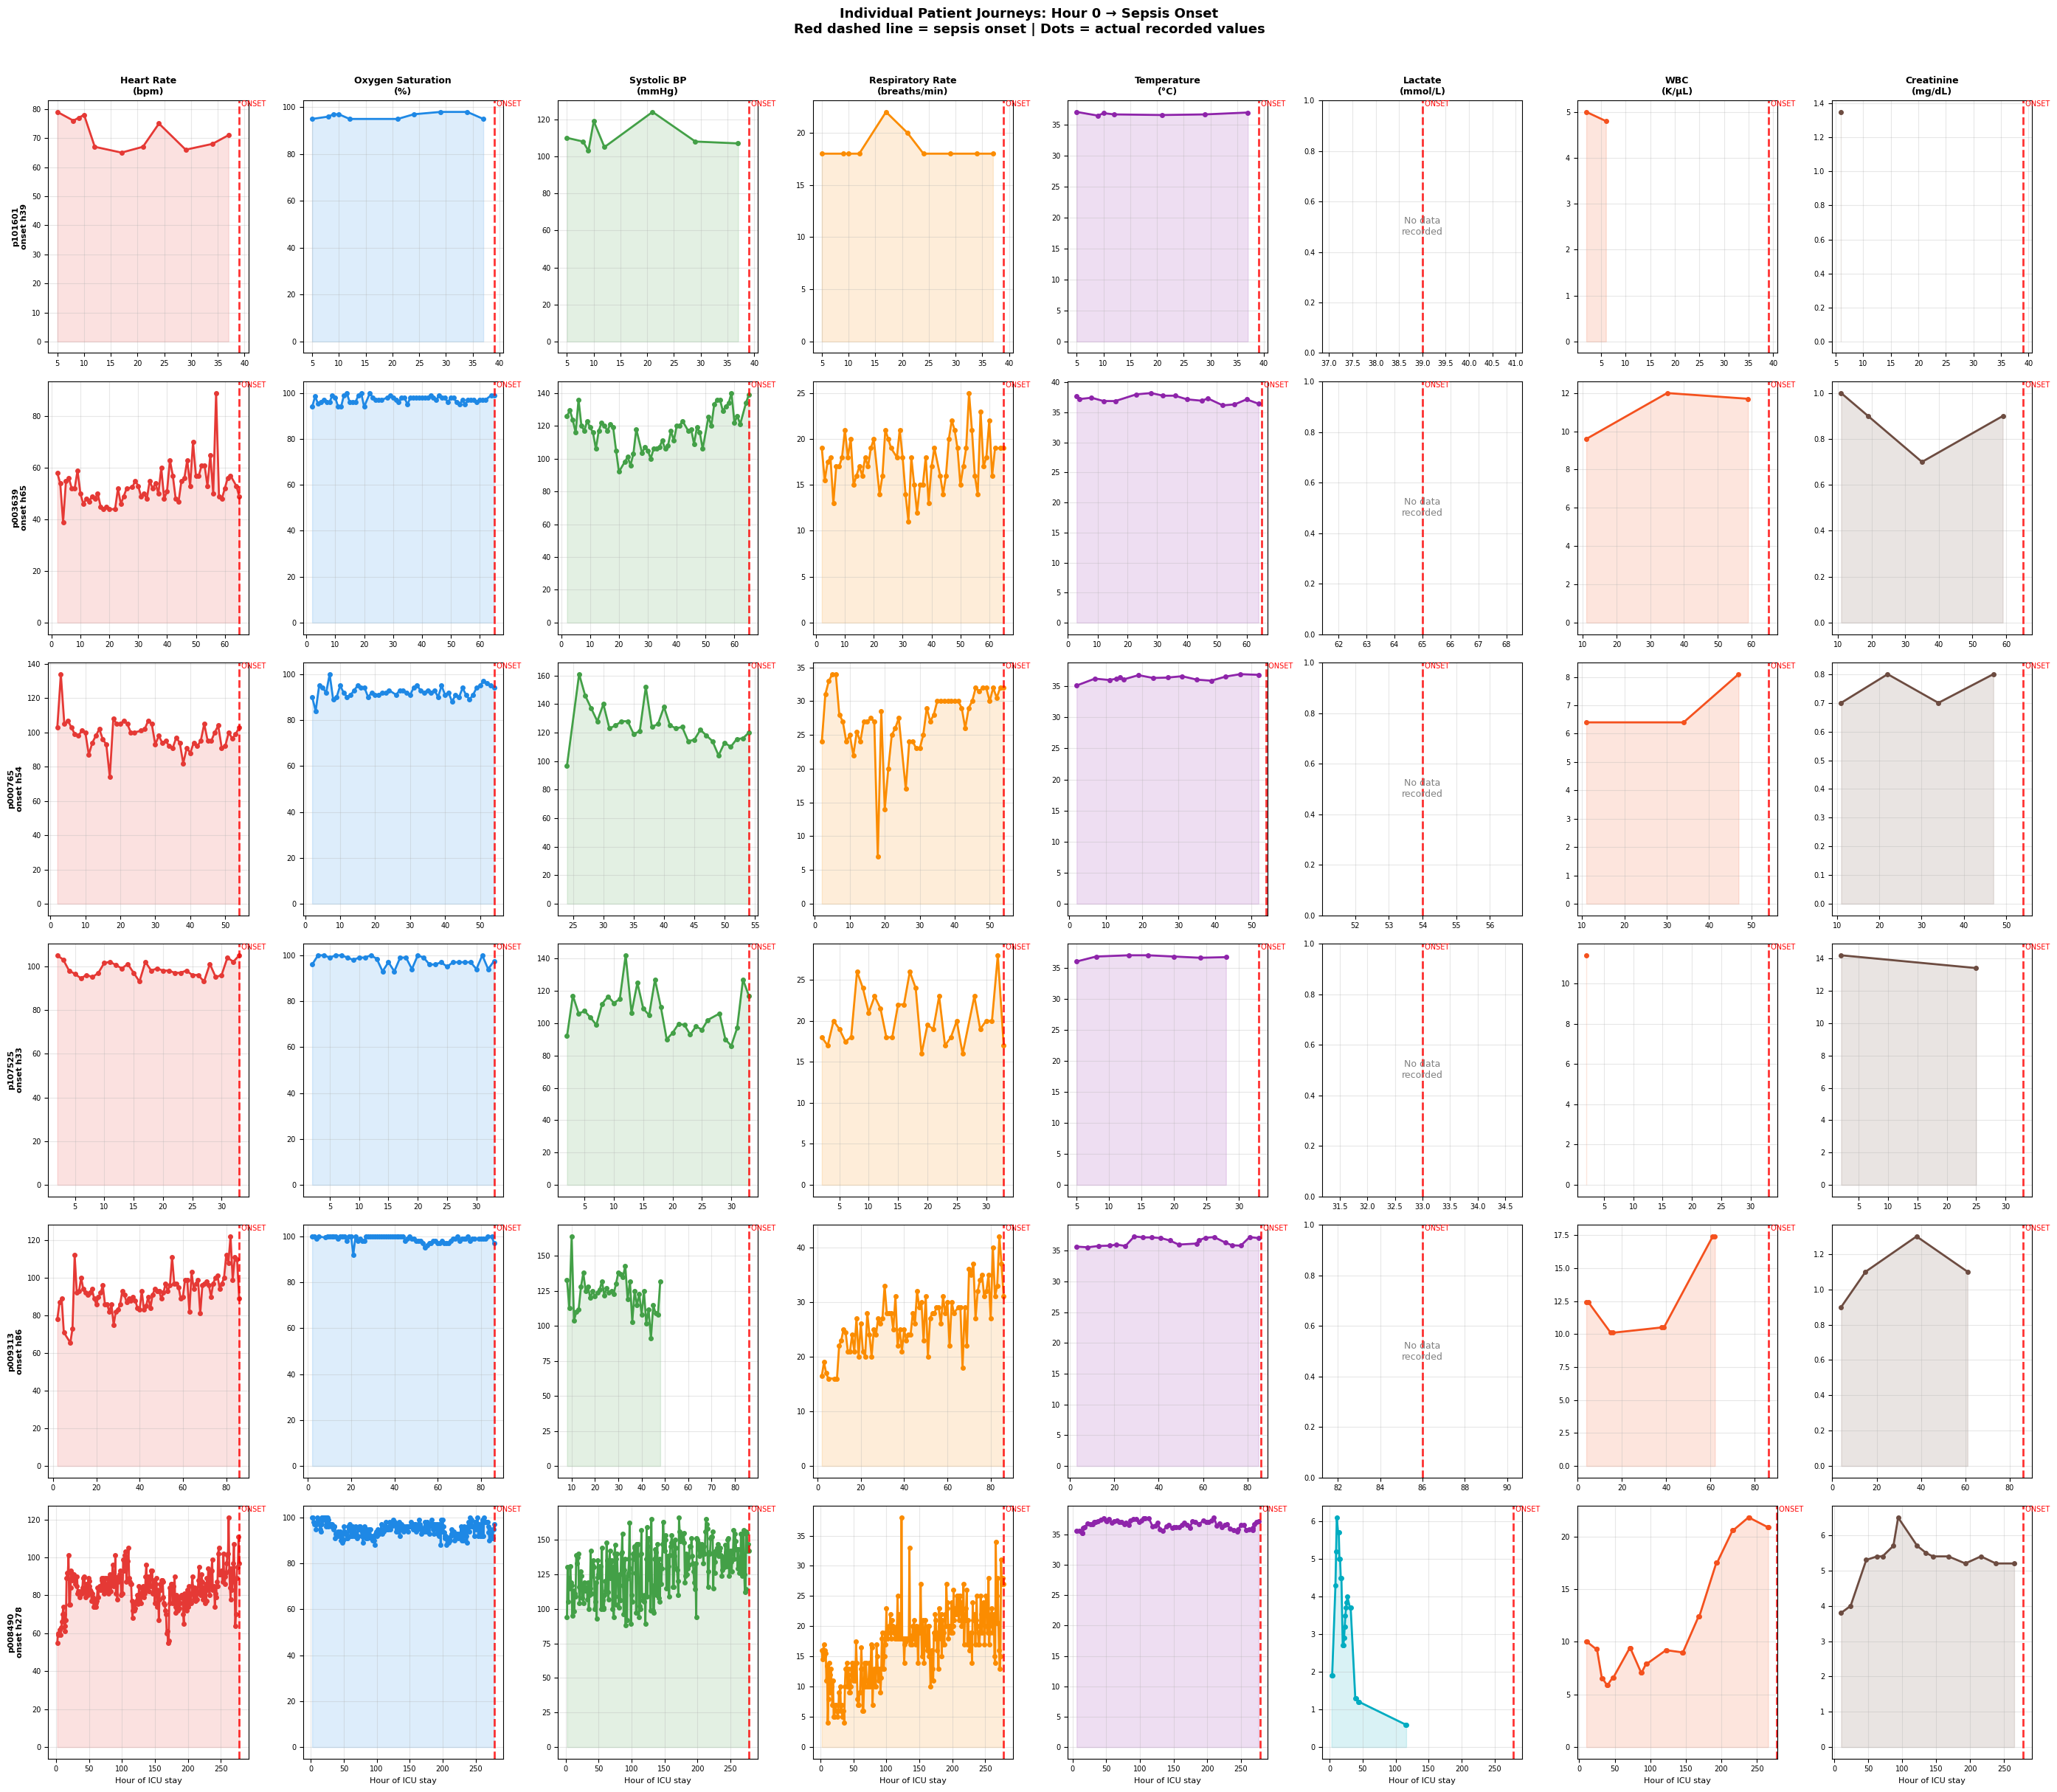

Chart saved to reports/patient_journeys.png


In [14]:
# Patient journey visualisation
# For each patient: vitals and labs from hour 0 to sepsis onset

features_to_plot = {
    'HR': ('Heart Rate', 'bpm', '#E53935'),
    'O2Sat': ('Oxygen Saturation', '%', '#1E88E5'),
    'SBP': ('Systolic BP', 'mmHg', '#43A047'),
    'Resp': ('Respiratory Rate', 'breaths/min', '#FB8C00'),
    'Temp': ('Temperature', '°C', '#8E24AA'),
    'Lactate': ('Lactate', 'mmol/L', '#00ACC1'),
    'WBC': ('WBC', 'K/μL', '#F4511E'),
    'Creatinine': ('Creatinine', 'mg/dL', '#6D4C41'),
}

fig, axes = plt.subplots(
    len(selected_patients), 
    len(features_to_plot), 
    figsize=(28, 4 * len(selected_patients))
)

for row, pid in enumerate(selected_patients):
    onset = onset_hours[pid]
    
    # Get this patient's data from hour 0 to onset
    patient_df = df[
        (df['patient_id'] == pid) & 
        (df['ICULOS'] <= onset)
    ].sort_values('ICULOS')
    
    for col, (feat, (label, unit, color)) in enumerate(
        zip(features_to_plot.keys(), 
            [(v[0], v[1], v[2]) for v in features_to_plot.values()])
    ):
        ax = axes[row][col]
        
        hours = patient_df['ICULOS']
        values = patient_df[feat]
        
        # Plot the line for non-missing values
        valid = patient_df[['ICULOS', feat]].dropna()
        
        if len(valid) > 0:
            ax.plot(valid['ICULOS'], valid[feat], 
                   color=color, linewidth=2, marker='o', 
                   markersize=4, label=feat)
            
            # Shade the area under the line
            ax.fill_between(valid['ICULOS'], valid[feat], 
                          alpha=0.15, color=color)
        else:
            ax.text(0.5, 0.5, 'No data\nrecorded', 
                   ha='center', va='center',
                   transform=ax.transAxes,
                   fontsize=9, color='gray')
        
        # Mark sepsis onset with vertical red line
        ax.axvline(x=onset, color='red', linestyle='--', 
                  linewidth=2, alpha=0.8)
        
        # Add small "SEPSIS" label at onset line
        ax.text(onset, ax.get_ylim()[1] if len(valid) > 0 else 1, 
               ' ONSET', color='red', fontsize=7,
               verticalalignment='top')
        
        # Labels
        if row == 0:
            ax.set_title(f'{label}\n({unit})', 
                        fontweight='bold', fontsize=9)
        if col == 0:
            ax.set_ylabel(f'{pid}\nonset h{onset}', 
                         fontsize=8, fontweight='bold')
        if row == len(selected_patients) - 1:
            ax.set_xlabel('Hour of ICU stay', fontsize=8)
            
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=7)

plt.suptitle('Individual Patient Journeys: Hour 0 → Sepsis Onset\n'
             'Red dashed line = sepsis onset | Dots = actual recorded values',
             fontsize=13, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('../reports/patient_journeys.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to reports/patient_journeys.png")

In [15]:
# Focused comparison: sepsis vs non-sepsis around average onset hour

# Average onset was ~51 hours, median was 29 hours
# Let's use median (29h) as it's more representative
# Find sepsis patients with onset between 25-35 hours (close to median)

target_onset_min = 25
target_onset_max = 35

focused_sepsis_ids = onset_hours[
    (onset_hours >= target_onset_min) & 
    (onset_hours <= target_onset_max)
].index.tolist()

print(f"Sepsis patients with onset between hour {target_onset_min}-{target_onset_max}:")
print(f"Found: {len(focused_sepsis_ids)} patients")

# Pick 4 of them
random.seed(123)
focused_selected = random.sample(focused_sepsis_ids, 4)
print(f"\nSelected: {focused_selected}")
for pid in focused_selected:
    print(f"  {pid}: sepsis at hour {onset_hours[pid]}")

# Pick 4 non-sepsis patients with at least 35 hours of stay
non_sepsis_ids = df[~df['patient_id'].isin(sepsis_ids)]['patient_id'].unique()
non_sepsis_stays = df[df['patient_id'].isin(non_sepsis_ids)].groupby('patient_id')['ICULOS'].max()
long_non_sepsis = non_sepsis_stays[non_sepsis_stays >= 35].index.tolist()

random.seed(456)
focused_normal = random.sample(long_non_sepsis, 4)
print(f"\nNon-sepsis patients selected: {focused_normal}")

Sepsis patients with onset between hour 25-35:
Found: 262 patients

Selected: ['p003075', 'p017854', 'p005038', 'p109197']
  p003075: sepsis at hour 35
  p017854: sepsis at hour 33
  p005038: sepsis at hour 26
  p109197: sepsis at hour 25

Non-sepsis patients selected: ['p104763', 'p105689', 'p103958', 'p101399']


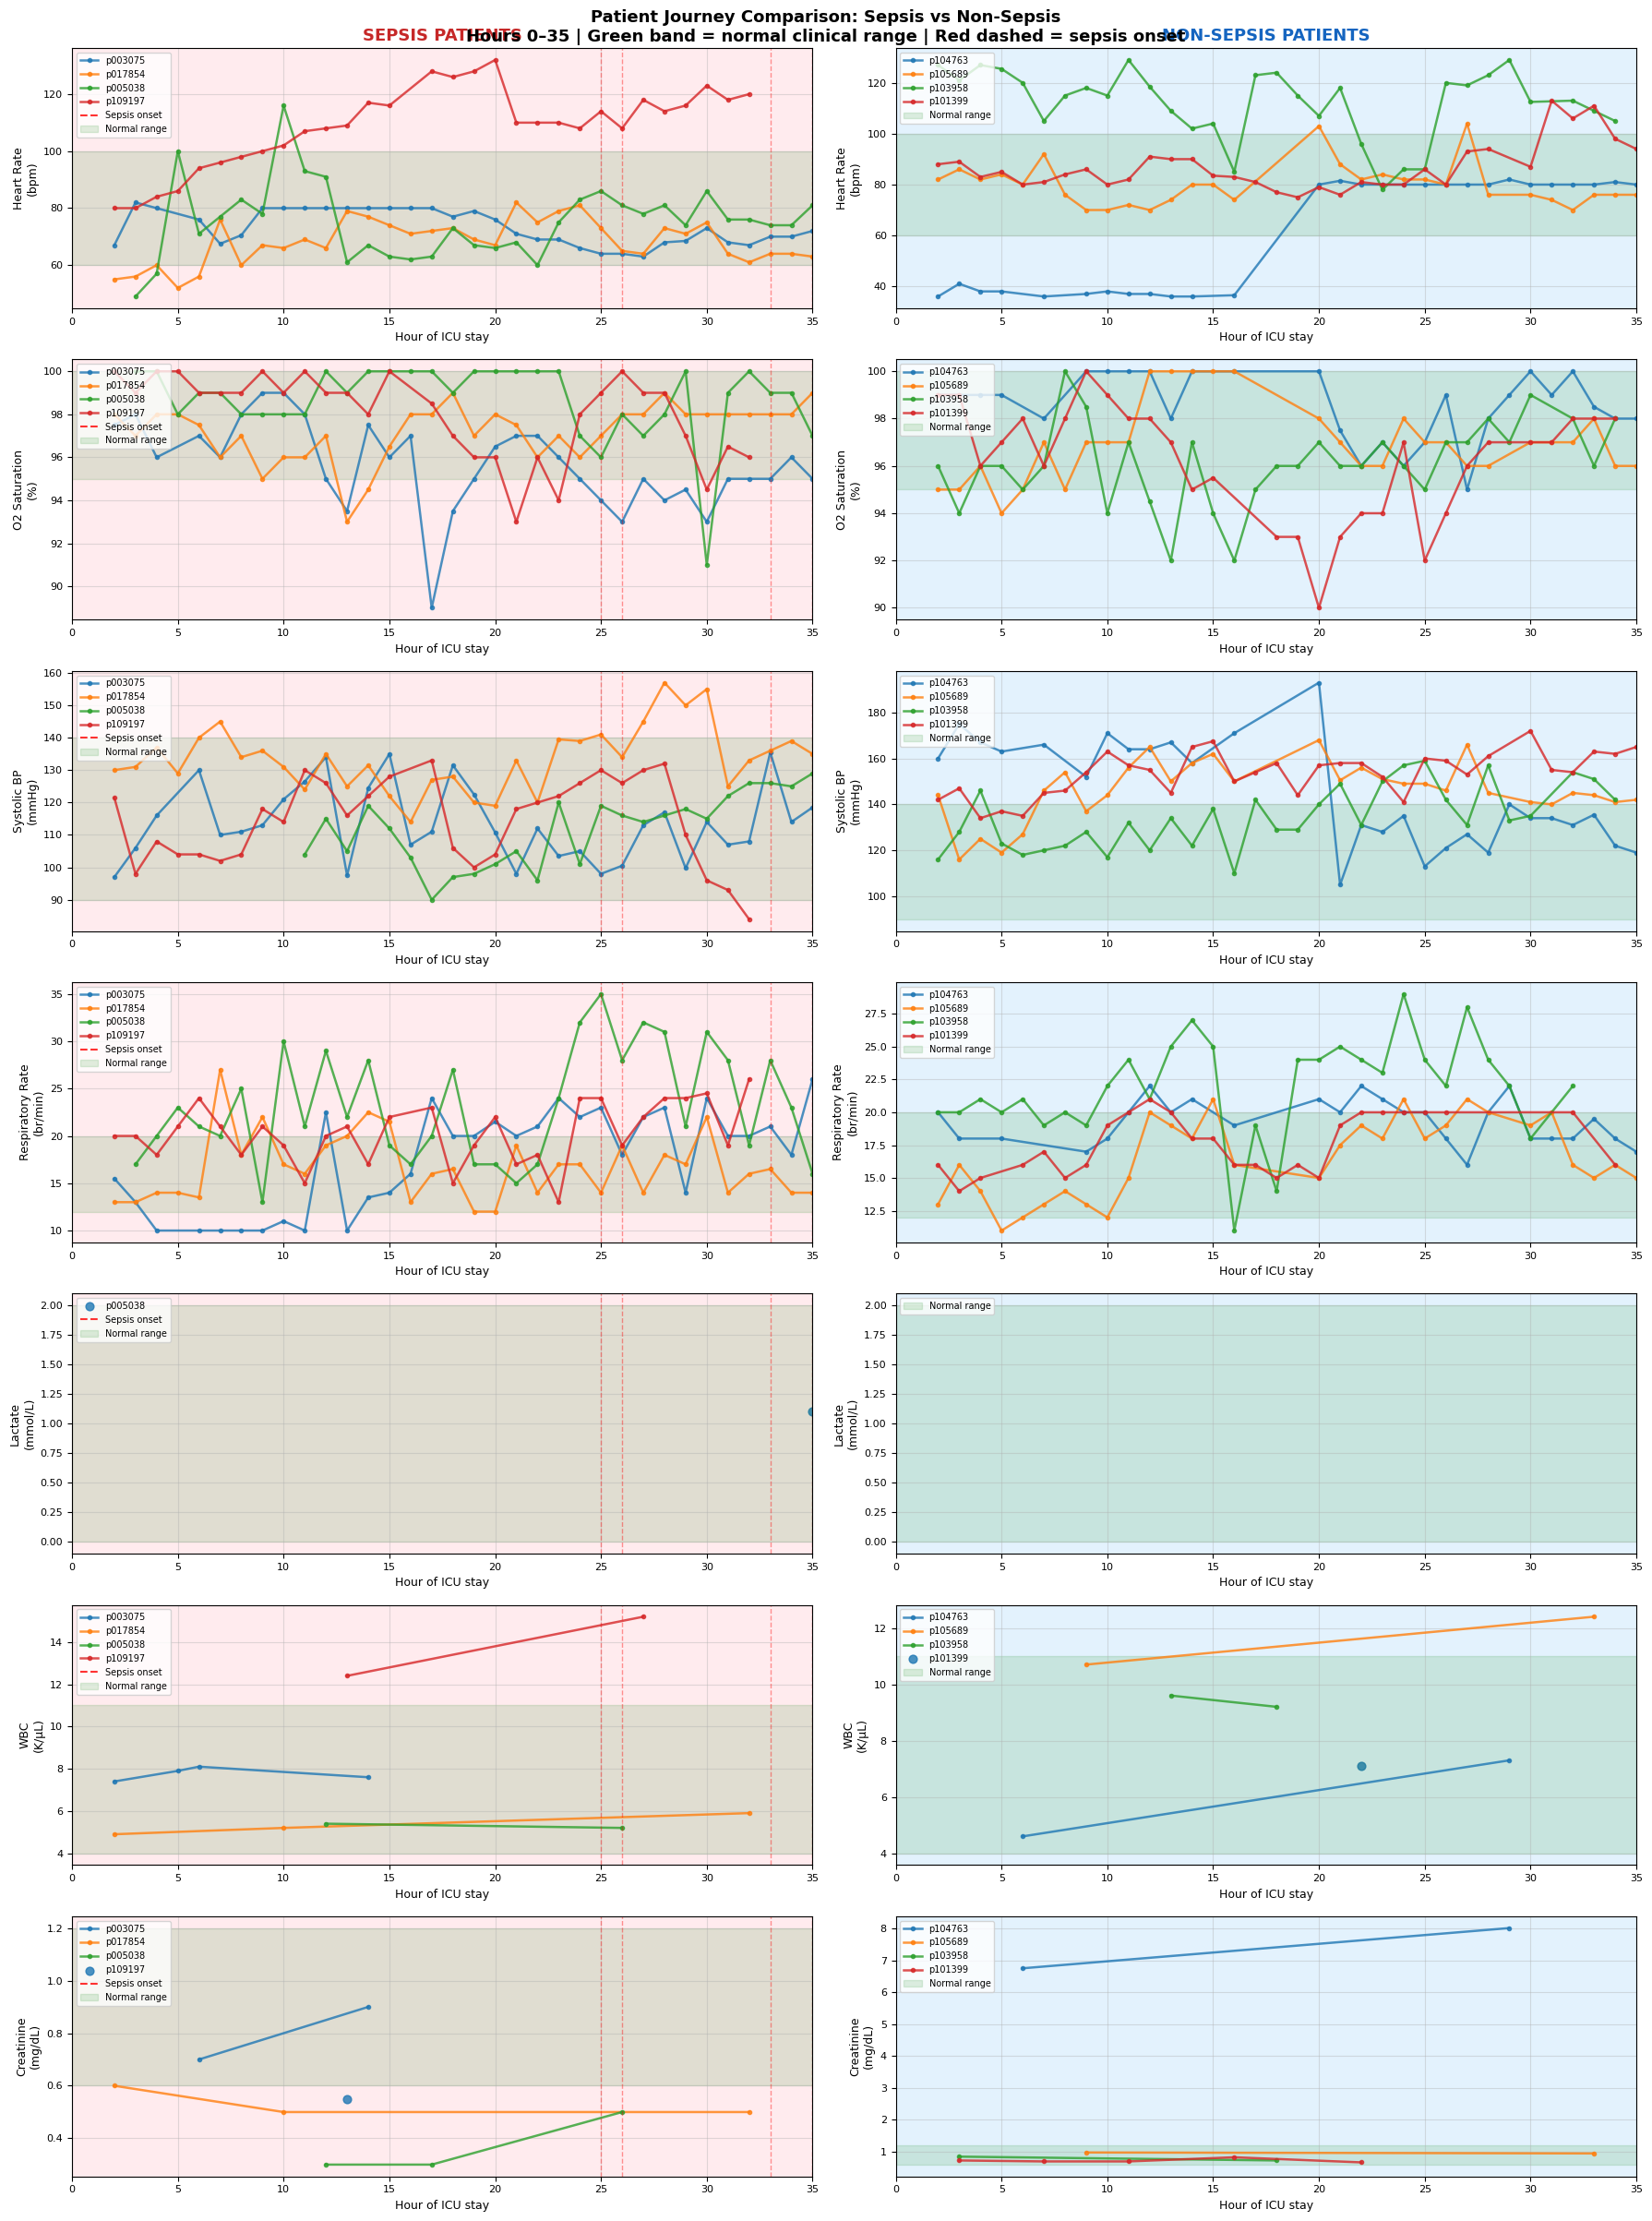

Chart saved to reports/sepsis_vs_normal_comparison.png


In [16]:
# Clean side by side comparison
# Sepsis patients (left) vs Non-sepsis patients (right)
# Only showing hours 0-35 for fair comparison

features_to_plot = {
    'HR':         ('Heart Rate',        'bpm',      '#E53935'),
    'O2Sat':      ('O2 Saturation',     '%',        '#1E88E5'),
    'SBP':        ('Systolic BP',       'mmHg',     '#43A047'),
    'Resp':       ('Respiratory Rate',  'br/min',   '#FB8C00'),
    'Lactate':    ('Lactate',           'mmol/L',   '#00ACC1'),
    'WBC':        ('WBC',               'K/μL',     '#F4511E'),
    'Creatinine': ('Creatinine',        'mg/dL',    '#6D4C41'),
}

MAX_HOUR = 35
n_features = len(features_to_plot)

fig, axes = plt.subplots(
    n_features, 2, 
    figsize=(18, n_features * 3.5)
)

for col_idx, (patient_group, group_label, group_color, show_onset) in enumerate([
    (focused_selected, 'SEPSIS PATIENTS',    '#FFEBEE', True),
    (focused_normal,   'NON-SEPSIS PATIENTS','#E3F2FD', False),
]):
    for row_idx, (feat, (label, unit, color)) in enumerate(features_to_plot.items()):
        ax = axes[row_idx][col_idx]
        
        # Light background to distinguish groups
        ax.set_facecolor(group_color)
        
        # Plot each patient as a separate line
        for pid in patient_group:
            patient_df = df[
                (df['patient_id'] == pid) & 
                (df['ICULOS'] <= MAX_HOUR)
            ].sort_values('ICULOS')
            
            valid = patient_df[['ICULOS', feat]].dropna()
            
            if len(valid) >= 2:
                ax.plot(valid['ICULOS'], valid[feat],
                       linewidth=1.8, marker='o', markersize=3,
                       alpha=0.8, label=pid)
            elif len(valid) == 1:
                ax.scatter(valid['ICULOS'], valid[feat],
                          s=40, alpha=0.8, label=pid)
        
        # Add sepsis onset markers for sepsis patients
        if show_onset:
            for pid in patient_group:
                onset = onset_hours[pid]
                if onset <= MAX_HOUR:
                    ax.axvline(x=onset, color='red', 
                              linestyle='--', linewidth=1, 
                              alpha=0.4)
            # One label for the legend
            ax.axvline(x=-1, color='red', linestyle='--', 
                      linewidth=1.5, alpha=0.8, 
                      label='Sepsis onset')

        # Add clinical reference ranges as shaded zones
        ref_ranges = {
            'HR':         (60, 100),
            'O2Sat':      (95, 100),
            'SBP':        (90, 140),
            'Resp':       (12, 20),
            'Lactate':    (0,  2),
            'WBC':        (4,  11),
            'Creatinine': (0.6, 1.2),
        }
        if feat in ref_ranges:
            low, high = ref_ranges[feat]
            ax.axhspan(low, high, alpha=0.12, 
                      color='green', label='Normal range')

        # Formatting
        if row_idx == 0:
            ax.set_title(f'{group_label}', 
                        fontsize=13, fontweight='bold',
                        color='#C62828' if col_idx == 0 else '#1565C0')
        
        ax.set_ylabel(f'{label}\n({unit})', fontsize=9)
        ax.set_xlabel('Hour of ICU stay', fontsize=9)
        ax.set_xlim(0, MAX_HOUR)
        ax.grid(True, alpha=0.4)
        ax.legend(fontsize=7, loc='upper left')
        ax.tick_params(labelsize=8)

plt.suptitle(
    'Patient Journey Comparison: Sepsis vs Non-Sepsis\n'
    'Hours 0–35 | Green band = normal clinical range | '
    'Red dashed = sepsis onset',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../reports/sepsis_vs_normal_comparison.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to reports/sepsis_vs_normal_comparison.png")